# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vincentoei/flyrank-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Setup

Install the tools and import what we need. Every new warehouse notebook starts here.

In [1]:
%pip install -q duckdb pandas scikit-learn matplotlib

import os
import json
from datetime import datetime, timezone
import getpass
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

# Load .env so HF_TOKEN is available without a prompt
env_path = Path.cwd().parents[1] / '.env'
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            key, value = line.split('=', 1)
            os.environ.setdefault(key, value)

Note: you may need to restart the kernel to use updated packages.


## 2. Load the honest feature vector

Reuse the same windows and filters from `w03_feature_leakage_check.ipynb`:

- Decision date: 2026-03-31
- Feature window: 2026-01-01 to 2026-03-31
- Target window: 2026-04-01 to 2026-04-30

The label is the only future-looking column.

In [2]:
# Load Hugging Face token without hard-coding it
token = os.getenv('HF_TOKEN')
if not token:
    token = getpass.getpass('Hugging Face token: ')

conn = duckdb.connect()
conn.execute('INSTALL httpfs;')
conn.execute('LOAD httpfs;')
conn.execute(f'''
    CREATE OR REPLACE SECRET hf_token (
        TYPE HTTP,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {token}'
        }}
    );
''')

conn.execute('''
    CREATE OR REPLACE VIEW dim_content AS
    SELECT * FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')
''')

conn.execute('''
    CREATE OR REPLACE VIEW dim_clients AS
    SELECT * FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet')
''')

print('Warehouse views attached.')

Warehouse views attached.


In [3]:
fv_query = '''
    WITH feature_window AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS gsc_impressions_90d,
            AVG(gsc_avg_position) AS gsc_avg_position_90d,
            SUM(gsc_clicks) AS gsc_clicks_90d,
            CASE WHEN SUM(gsc_impressions) > 0 THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions) ELSE 0 END AS gsc_ctr_90d,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_organic ELSE 0 END) AS sessions_organic_90d,
            COUNT(DISTINCT report_date) AS days_with_impressions_90d
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-0[1-3]/*.parquet')
        WHERE report_date BETWEEN '2026-01-01' AND '2026-03-31'
        GROUP BY client_hash_id, content_hash_id
    ),
    last_30 AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS gsc_impressions_last_30d
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
        GROUP BY client_hash_id, content_hash_id
    ),
    label_window AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS gsc_impressions_next_30d
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet')
        WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
        GROUP BY client_hash_id, content_hash_id
    ),
    decision_date AS (
        SELECT DATE '2026-03-31' AS d
    )
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.gsc_impressions_90d,
        f.gsc_avg_position_90d,
        f.gsc_clicks_90d,
        f.gsc_ctr_90d,
        f.sessions_organic_90d,
        f.days_with_impressions_90d,
        l30.gsc_impressions_last_30d,
        l.gsc_impressions_next_30d,
        dim_content.search_volume,
        dim_content.competition,
        dim_content.cpc,
        dim_content.word_count,
        dim_content.content_type,
        dim_content.main_intent,
        (d.d - dim_content.content_created_date)::INTEGER AS content_age_days,
        CASE
            WHEN l.gsc_impressions_next_30d >= 1.20 * l30.gsc_impressions_last_30d
                 AND l30.gsc_impressions_last_30d >= 100
            THEN 1 ELSE 0
        END AS growth_label
    FROM feature_window f
    LEFT JOIN last_30 l30 ON f.content_hash_id = l30.content_hash_id
    LEFT JOIN label_window l ON f.content_hash_id = l.content_hash_id
    LEFT JOIN dim_content ON f.content_hash_id = dim_content.content_hash_id
    CROSS JOIN decision_date d
    WHERE f.gsc_impressions_90d >= 300
      AND dim_content.content_created_date <= d.d
      AND dim_content.word_count IS NOT NULL
'''

feature_vector = conn.execute(fv_query).df()
print(f'Rows: {len(feature_vector):,}')
print(f'Positive growth rate: {feature_vector["growth_label"].mean():.3%}')
print(feature_vector.head(3))

# Window sanity check
window_check = conn.execute('''
    SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-0[1-3]/*.parquet')
    WHERE report_date BETWEEN '2026-01-01' AND '2026-03-31'
''').df()
print('\nFeature window span:')
print(window_check.to_string(index=False))
assert window_check['max_date'].iloc[0] <= pd.Timestamp('2026-03-31'), 'Feature window leaks into April!'

Rows: 67,478
Positive growth rate: 24.731%
            client_hash_id           content_hash_id  gsc_impressions_90d  \
0  client_400c21c81c8b46ef  content_94148e3bea01e0c7                704.0   
1  client_400c21c81c8b46ef  content_20951db0d80df60a                577.0   
2  client_400c21c81c8b46ef  content_4deec3e08daa108d                404.0   

   gsc_avg_position_90d  gsc_clicks_90d  gsc_ctr_90d  sessions_organic_90d  \
0             14.091946             3.0     0.004261                   0.0   
1             13.677524             0.0     0.000000                   0.0   
2              7.842400             0.0     0.000000                   0.0   

   days_with_impressions_90d  gsc_impressions_last_30d  \
0                         90                     217.0   
1                         90                     202.0   
2                         90                     159.0   

   gsc_impressions_next_30d  search_volume  competition  cpc  word_count  \
0                      46.


Feature window span:
  min_date   max_date
2026-01-01 2026-03-31


In [4]:
# Verdict helpers
def spearman_rank_corr(x, y):
    xr = pd.Series(x).rank()
    yr = pd.Series(y).rank()
    return float(np.corrcoef(xr, yr)[0, 1])

def verdict_quintiles(table, base_rate, floor=50):
    rates = table['growth_rate'].tolist()
    ns = table['n'].tolist()
    if any(n < floor for n in ns):
        return 'MIXED — at least one bucket is below the sample-size floor.'
    if all(rates[i] <= rates[i + 1] for i in range(len(rates) - 1)) and rates[-1] > base_rate:
        return 'CONFIRMED — growth rate rises monotonically with the signal.'
    if all(rates[i] >= rates[i + 1] for i in range(len(rates) - 1)) and rates[0] > base_rate:
        return 'OPPOSITE — growth rate falls as the signal rises.'
    return 'MIXED — no clear monotonic relationship across buckets.'

def verdict_categorical(table, base_rate, floor=50):
    big = table[table['n'] >= floor]
    if big.empty:
        return 'MIXED — no bucket meets the sample-size floor.'
    best = big.loc[big['growth_rate'].idxmax()]
    if best['growth_rate'] > base_rate * 1.1:
        return f'CONFIRMED — {best.iloc[0]} pages grow more often than average.'
    return 'MIXED — no category shows a strong growth association.'

def verdict_flag(thin_rate, not_thin_rate, thin_n, not_thin_n, floor=50):
    if thin_n < floor or not_thin_n < floor:
        return 'MIXED — one group is below the sample-size floor.'
    if thin_rate > not_thin_rate * 1.05:
        return 'CONFIRMED — thin visible pages grow more often than non-thin visible pages.'
    if thin_rate < not_thin_rate * 0.95:
        return 'OPPOSITE — thin visible pages grow less often than non-thin visible pages.'
    return 'MIXED — thin and non-thin visible pages grow at similar rates.'

## 3. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [5]:
numeric_cols = [
    'gsc_impressions_90d', 'gsc_impressions_last_30d', 'gsc_avg_position_90d',
    'gsc_ctr_90d', 'word_count', 'content_age_days', 'days_with_impressions_90d'
]
print('Numeric summary:')
print(feature_vector[numeric_cols].describe().round(2))

print('\nMissing values:')
print(feature_vector.isnull().mean().round(3).to_string())

print('\nCategorical counts:')
for col in ['content_type', 'main_intent']:
    print(f'\n{col}:')
    print(feature_vector[col].value_counts(dropna=False).head(10).to_string())

Numeric summary:
       gsc_impressions_90d  gsc_impressions_last_30d  gsc_avg_position_90d  \
count             67478.00                  64456.00              67478.00   
mean               7328.61                   3667.98                 11.53   
std               16693.87                   7994.28                  9.61   
min                 300.00                      0.00                  0.05   
25%                 846.00                    531.00                  5.02   
50%                2370.00                   1377.00                  8.25   
75%                7333.00                   3840.00                 15.24   
max              830289.00                 617124.00                 92.02   

       gsc_ctr_90d  word_count  content_age_days  days_with_impressions_90d  
count     67478.00    67478.00          67478.00                   67478.00  
mean          0.00     2940.68            170.67                      71.06  
std           0.00     1127.89            116.

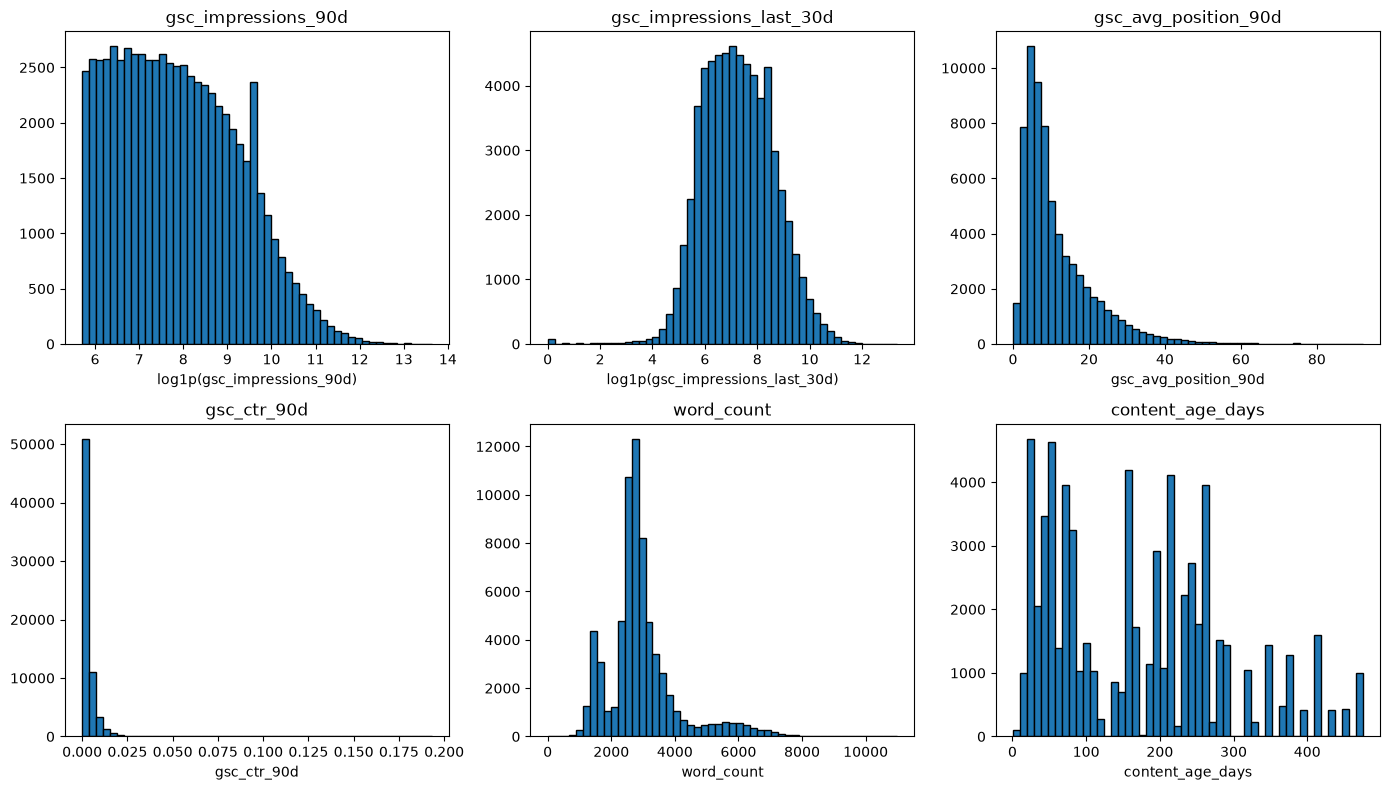

Key distribution notes:
- Impression columns are heavy-tailed; use log1p or ranks for correlations.
- Average position is bounded but has a long tail into deep pages.
- CTR has many zeros and a few very high values.
- Content age spans from brand-new pages to old pages; shown as backdrop, not a formal test.


In [6]:
# Plot distributions. Use log1p for heavy-tailed impression columns.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
plot_cols = [
    'gsc_impressions_90d', 'gsc_impressions_last_30d', 'gsc_avg_position_90d',
    'gsc_ctr_90d', 'word_count', 'content_age_days'
]
for ax, col in zip(axes, plot_cols):
    data = feature_vector[col].replace([np.inf, -np.inf], np.nan).dropna()
    if 'impressions' in col:
        data = np.log1p(data)
        ax.set_xlabel(f'log1p({col})')
    else:
        ax.set_xlabel(col)
    ax.hist(data, bins=50, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print('Key distribution notes:')
print('- Impression columns are heavy-tailed; use log1p or ranks for correlations.')
print('- Average position is bounded but has a long tail into deep pages.')
print('- CTR has many zeros and a few very high values.')
print('- Content age spans from brand-new pages to old pages; shown as backdrop, not a formal test.')

## 4. Signal test #1 — Recent impression concentration

**Claim:** Pages with a larger share of their 90-day impressions in the last 30 days are more likely to grow.

**Test:** Bucket pages into quintiles of `recent_share = gsc_impressions_last_30d / gsc_impressions_90d` and compare growth rates.

In [7]:
df1 = feature_vector.dropna(subset=['gsc_impressions_last_30d', 'gsc_impressions_90d']).copy()
df1['recent_share'] = (df1['gsc_impressions_last_30d'] / df1['gsc_impressions_90d']).clip(0, 1)
base_rate_1 = df1['growth_label'].mean()
df1['recent_share_quintile'] = pd.qcut(df1['recent_share'], q=5, duplicates='drop')

table1 = df1.groupby('recent_share_quintile', observed=True).agg(
    n=('growth_label', 'size'),
    growth_rate=('growth_label', 'mean'),
    median_recent_share=('recent_share', 'median')
).reset_index()
table1['lift_over_base'] = table1['growth_rate'] - base_rate_1
print(f'Base growth rate: {base_rate_1:.3%}')
print(table1.to_string(index=False))

rho1 = spearman_rank_corr(df1['recent_share'], df1['growth_label'])
print(f'\nSpearman rank correlation with growth: {rho1:.3f}')

verdict1 = verdict_quintiles(table1, base_rate_1)
print(f'\nVerdict: {verdict1}')

Base growth rate: 25.891%
recent_share_quintile     n  growth_rate  median_recent_share  lift_over_base
      (-0.001, 0.346] 12892     0.233401             0.293266       -0.025505
        (0.346, 0.45] 12891     0.165387             0.396307       -0.093519
        (0.45, 0.608] 12891     0.177721             0.515625       -0.081184
       (0.608, 0.884] 12891     0.233574             0.731384       -0.025331
         (0.884, 1.0] 12891     0.484447             1.000000        0.225541

Spearman rank correlation with growth: 0.196

Verdict: MIXED — no clear monotonic relationship across buckets.


## 5. Signal test #2 — Days with impressions (consistency)

**Claim:** Pages that appear on more days in the 90-day window are more likely to grow.

**Test:** Bucket pages into quintiles of `days_with_impressions_90d` and compare growth rates.

In [8]:
df2 = feature_vector.copy()
base_rate_2 = df2['growth_label'].mean()
df2['days_quintile'] = pd.qcut(df2['days_with_impressions_90d'], q=5, duplicates='drop')

table2 = df2.groupby('days_quintile', observed=True).agg(
    n=('growth_label', 'size'),
    growth_rate=('growth_label', 'mean'),
    median_days=('days_with_impressions_90d', 'median')
).reset_index()
table2['lift_over_base'] = table2['growth_rate'] - base_rate_2
print(f'Base growth rate: {base_rate_2:.3%}')
print(table2.to_string(index=False))

rho2 = spearman_rank_corr(df2['days_with_impressions_90d'], df2['growth_label'])
print(f'\nSpearman rank correlation with growth: {rho2:.3f}')

verdict2 = verdict_quintiles(table2, base_rate_2)
print(f'\nVerdict: {verdict2}')

Base growth rate: 24.731%
days_quintile     n  growth_rate  median_days  lift_over_base
(6.999, 41.0] 17761     0.386352         41.0        0.139042
 (41.0, 81.0]  9260     0.172570         54.0       -0.074740
 (81.0, 90.0] 40457     0.203376         90.0       -0.043934

Spearman rank correlation with growth: -0.179

Verdict: MIXED — no clear monotonic relationship across buckets.


## 6. Signal test #3 — Main intent

**Claim:** Search intent is associated with 30-day impression growth.

**Test:** Compare growth rates across `main_intent` buckets. Missing intent is shown as `unknown`.

In [9]:
df3 = feature_vector.copy()
df3['main_intent'] = df3['main_intent'].fillna('unknown')
base_rate_3 = df3['growth_label'].mean()

table3 = df3.groupby('main_intent').agg(
    n=('growth_label', 'size'),
    growth_rate=('growth_label', 'mean')
).reset_index().sort_values('growth_rate', ascending=False)
table3['lift_over_base'] = table3['growth_rate'] - base_rate_3
print(f'Base growth rate: {base_rate_3:.3%}')
print(table3.to_string(index=False))

verdict3 = verdict_categorical(table3, base_rate_3)
print(f'\nVerdict: {verdict3}')

Base growth rate: 24.731%
  main_intent     n  growth_rate  lift_over_base
informational 40051     0.272053        0.024743
   commercial 12018     0.225745       -0.021566
transactional 13863     0.207675       -0.039635
 navigational   176     0.142045       -0.105265
      unknown  1370     0.127737       -0.119573

Verdict: CONFIRMED — informational pages grow more often than average.


## 7. The flag-linked test — Thin visible page

FlyRank's starter baseline uses the rule:

```
thin_visible_page = word_count > 0 and word_count < 1200 and impressions_90d >= 250
```

**Claim:** Thin but visible pages are more likely to grow.

**Test:** Within pages with `gsc_impressions_90d >= 250`, compare growth rates for thin vs non-thin pages.

In [10]:
visible = feature_vector[feature_vector['gsc_impressions_90d'] >= 250].copy()
visible['thin'] = (visible['word_count'] > 0) & (visible['word_count'] < 1200)
base_rate_flag = visible['growth_label'].mean()

table_flag = visible.groupby('thin').agg(
    n=('growth_label', 'size'),
    growth_rate=('growth_label', 'mean')
).reset_index()
table_flag['category'] = table_flag['thin'].map({True: 'thin_visible_page', False: 'not_thin_visible'})
table_flag['lift_over_base'] = table_flag['growth_rate'] - base_rate_flag
print(f'Visible subset rows: {len(visible):,}')
print(f'Base growth rate in visible subset: {base_rate_flag:.3%}')
print(table_flag[['category', 'n', 'growth_rate', 'lift_over_base']].to_string(index=False))

thin_row = table_flag[table_flag['category'] == 'thin_visible_page'].iloc[0]
not_thin_row = table_flag[table_flag['category'] == 'not_thin_visible'].iloc[0]
verdict_flag_text = verdict_flag(
    thin_row['growth_rate'], not_thin_row['growth_rate'],
    int(thin_row['n']), int(not_thin_row['n'])
)
print(f'\nVerdict: {verdict_flag_text}')

Visible subset rows: 67,478
Base growth rate in visible subset: 24.731%
         category     n  growth_rate  lift_over_base
 not_thin_visible 66847     0.248149        0.000839
thin_visible_page   631     0.158479       -0.088832

Verdict: OPPOSITE — thin visible pages grow less often than non-thin visible pages.


## 8. What this means in practice

*Two or three sentences: what a content team should take from this.*

The verdicts above are observational, not causal. Use them to prioritize which pages a human reviewer should look at first, not as proof that editing a page will cause growth.

In [11]:
print('SIGNAL AUDIT SUMMARY')
print('=' * 60)
print(f'1. Recent impression concentration: {verdict1}')
print(f'2. Days with impressions:          {verdict2}')
print(f'3. Main intent:                    {verdict3}')
print(f'4. Thin visible page flag:         {verdict_flag_text}')
print('=' * 60)
print('\nTakeaway for the content team:')
print('- Rank pages by the signals that were CONFIRMED.')
print('- Treat MIXED or OPPOSITE signals as weak or contrary evidence.')
print('- Always pair the score with reason codes and a human review.')

SIGNAL AUDIT SUMMARY
1. Recent impression concentration: MIXED — no clear monotonic relationship across buckets.
2. Days with impressions:          MIXED — no clear monotonic relationship across buckets.
3. Main intent:                    CONFIRMED — informational pages grow more often than average.
4. Thin visible page flag:         OPPOSITE — thin visible pages grow less often than non-thin visible pages.

Takeaway for the content team:
- Rank pages by the signals that were CONFIRMED.
- Treat MIXED or OPPOSITE signals as weak or contrary evidence.
- Always pair the score with reason codes and a human review.


## 9. Optional top-20 review

Use the same momentum-with-volume score from `w04_baseline_score.ipynb` to review the top 20 candidates.

For each row: action, why it is there, and what would make it wrong.

In [12]:
df_review = feature_vector.copy()
df_review['recent_share'] = (df_review['gsc_impressions_last_30d'] / df_review['gsc_impressions_90d']).clip(0, 1).fillna(0)
df_review['score'] = np.where(
    df_review['gsc_impressions_90d'] >= 500,
    df_review['recent_share'] * np.log1p(df_review['gsc_impressions_90d']),
    0.0
)
df_review['rank'] = df_review['score'].rank(method='first', ascending=False).astype(int)
df_review['action'] = np.where(df_review['score'] > 0, 'expand_and_protect', 'monitor')

def review_note(row):
    return (
        f"Action: {row['action']} | "
        f"Why: {row['gsc_impressions_90d']:,.0f} 90d impressions, "
        f"{row['recent_share']:.1%} in last 30d | "
        f"Wrong if: the last-30d spike was a one-off event or seasonality."
    )

top20 = df_review.sort_values('rank').head(20).copy()
top20['review_note'] = top20.apply(review_note, axis=1)

print('TOP-20 REVIEW')
print('=' * 80)
for _, row in top20.iterrows():
    print(f"{row['rank']:>2}. {row['review_note']}")

print('\nTop-20 precision:')
print(f"  {top20['growth_label'].mean():.3%} actually grew")
audit_metrics = {
    'rows': int(len(feature_vector)),
    'base_growth_rate': float(feature_vector['growth_label'].mean()),
    'verdicts': {
        'recent_impression_concentration': verdict1,
        'days_with_impressions': verdict2,
        'main_intent': verdict3,
        'thin_visible_page': verdict_flag_text
    },
    'top20_precision': float(top20['growth_label'].mean()),
    'timestamp': datetime.now(timezone.utc).isoformat()
}
audit_metrics_path = Path.cwd().parent / 'outputs' / 'w04_signal_audit_metrics.json'
audit_metrics_path.parent.mkdir(parents=True, exist_ok=True)
with open(audit_metrics_path, 'w') as f:
    json.dump(audit_metrics, f, indent=2)
print(f'Metrics written to: {audit_metrics_path}')


TOP-20 REVIEW
 1. Action: expand_and_protect | Why: 89,874 90d impressions, 99.4% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 2. Action: expand_and_protect | Why: 83,788 90d impressions, 100.0% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 3. Action: expand_and_protect | Why: 91,150 90d impressions, 98.7% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 4. Action: expand_and_protect | Why: 82,991 90d impressions, 99.3% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 5. Action: expand_and_protect | Why: 108,584 90d impressions, 96.1% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 6. Action: expand_and_protect | Why: 63,257 90d impressions, 99.9% in last 30d | Wrong if: the last-30d spike was a one-off event or seasonality.
 7. Action: expand_and_protect | Why: 149,297 90d impressions, 92.4% in last 30d | Wrong if: the last-

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.